# Verification Task


In [19]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import importlib, src.models
importlib.reload(src.models)
from src.models import IsolationForestDetector, LOFDetector, OneClassSVMDetector

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130})

df = pd.read_csv('test_data.csv', index_col=0)
print(f'{df.shape}')
display(df.describe().round(3))


(3443, 21)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21
count,3443.000,3443.000,3443.000,3443.000,3443.000,3443.000,3443.000,3443.000,3443.000,3443.000,...,3443.000,3443.000,3443.000,3443.000,3443.000,3443.000,3443.000,3443.000,3443.000,3443.000
mean,0.022,0.258,0.514,0.758,0.994,1.742,2.481,2.717,2.966,3.440,...,3.469,2.997,2.749,2.518,1.809,1.042,0.791,0.518,0.284,-0.013
std,1.019,1.059,1.172,1.404,1.660,1.794,2.010,1.757,1.641,1.468,...,1.450,1.608,1.750,1.998,1.792,1.643,1.405,1.199,1.071,0.991
min,-2.950,-3.250,-4.200,-3.840,-3.480,-2.760,-3.320,-3.520,-3.380,-1.770,...,-1.610,-2.610,-2.370,-2.480,-2.990,-3.560,-3.190,-3.500,-3.570,-3.460
25%,-0.660,-0.460,-0.280,-0.260,-0.210,0.360,0.930,1.460,1.830,2.470,...,2.490,1.880,1.450,1.015,0.490,-0.180,-0.210,-0.330,-0.430,-0.660
50%,0.020,0.270,0.470,0.650,0.700,1.490,2.280,2.810,3.180,3.500,...,3.560,3.230,2.820,2.310,1.560,0.810,0.660,0.480,0.270,-0.020
75%,0.710,0.980,1.270,1.670,2.070,2.990,3.970,3.990,4.190,4.470,...,4.480,4.180,4.070,4.010,3.050,2.170,1.770,1.330,1.010,0.670
max,3.940,3.830,4.390,5.750,6.500,7.040,8.760,7.840,7.900,7.630,...,7.400,7.500,7.750,8.720,7.550,6.710,5.560,5.280,4.650,4.010


Points with any value > 1.5xIQR from quartile: 246 (7.1%)
Points with any value > 3.0xIQR from quartile: 0 (0.0%)


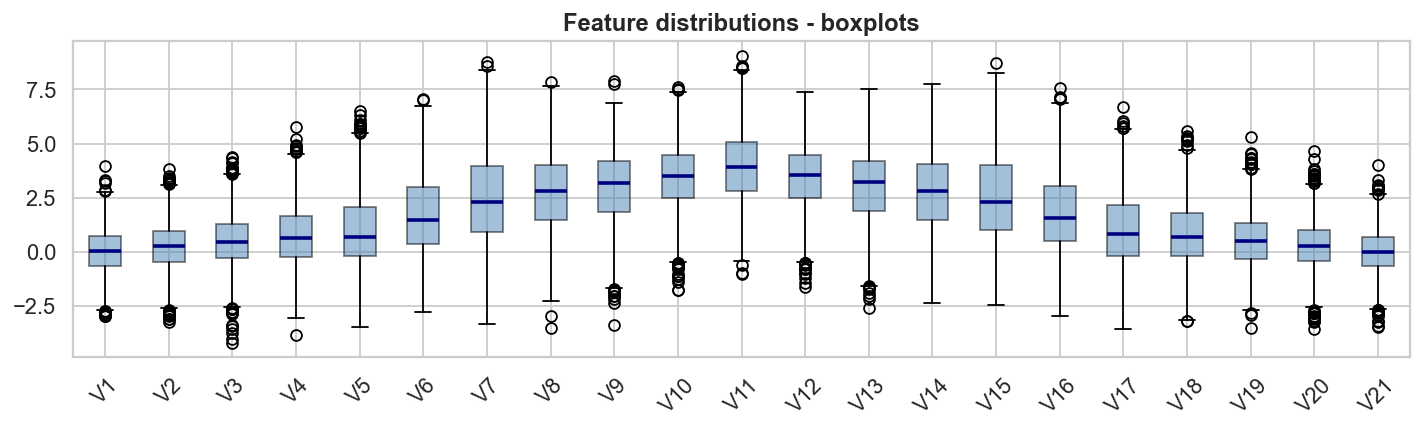

In [7]:
#estimating contamination via IQR bound (not used for actual detection, just to get a sense of the data)
Q1, Q3 = df.quantile(0.25), df.quantile(0.75)
IQR = Q3 - Q1
extreme_any = ((df < Q1 - 1.5*IQR) | (df > Q3 + 1.5*IQR)).any(axis=1)
extreme_strict = ((df < Q1 - 3.0*IQR) | (df > Q3 + 3.0*IQR)).any(axis=1)

print(f'Points with any value > 1.5xIQR from quartile: {extreme_any.sum()} ({extreme_any.mean():.1%})')
print(f'Points with any value > 3.0xIQR from quartile: {extreme_strict.sum()} ({extreme_strict.mean():.1%})')

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.boxplot(df.values, patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.5), medianprops=dict(color='navy', lw=2))
ax.set_xticks(range(1, len(df.columns)+1))
ax.set_xticklabels(df.columns, rotation=45)
ax.set_title('Feature distributions - boxplots', fontweight='bold')
plt.tight_layout()
plt.show()


## Main idea

goal: majority-vote ensemble of three detectors since no single algorithm was consistently the best across all dataset types

chosen models for an ensemble:
- Isolation Forest: global outliers detection, the most robust across dimensionalities and has stable defaults
- LOF: local outliers, might catch local outliers missed by global methods
- OC-SVM: different failure modes from both tree and density methods

point is labeled outlier if is flagged by at least 2 out of 3 methods (majority vote)


hyperparameters (based on previous hyperparameters analysis):

- contamination = 0.05 for all methods - consistent with IQR estimate above
- Isolation Forest: n_estimators=200 - stable beyond 100;
- LOF: n_neighbors=20 - safest option from n_neighbors sweep
- OC-SVM: kernel='rbf', gamma='scale' - only safe defaults


## Ensemble and Labelling

In [12]:
CONTAM = 0.05

scaler = RobustScaler()
Xs = scaler.fit_transform(df.values)

iso = IsolationForestDetector(n_estimators=200, contamination=CONTAM)
iso.fit(Xs)
scores_iso = iso.score_samples(Xs)

lof = LOFDetector(n_neighbors=20, contamination=CONTAM)
lof.fit(Xs)
scores_lof = lof.score_samples(Xs)

svm = OneClassSVMDetector(nu=CONTAM, kernel='rbf', gamma='scale')
svm.fit(Xs)
scores_svm = svm.score_samples(Xs)

flag = lambda s: (s >= np.percentile(s, 100*(1-CONTAM))).astype(int) #flag points above the contamination threshold for each method
votes = flag(scores_iso) + flag(scores_lof) + flag(scores_svm) #count how many methods flag each point as outlier
labels = (votes >= 2).astype(int)

print('Agreement:', pd.Series(votes).value_counts().sort_index().to_dict())
print(f'Outliers: {labels.sum()} ({labels.mean():.1%})')
print(f'\nFinal: {labels.sum()} outliers ({labels.mean():.1%})')


Agreement: {0: 3114, 1: 183, 2: 102, 3: 44}
Outliers: 146 (4.2%)

Final: 146 outliers (4.2%)


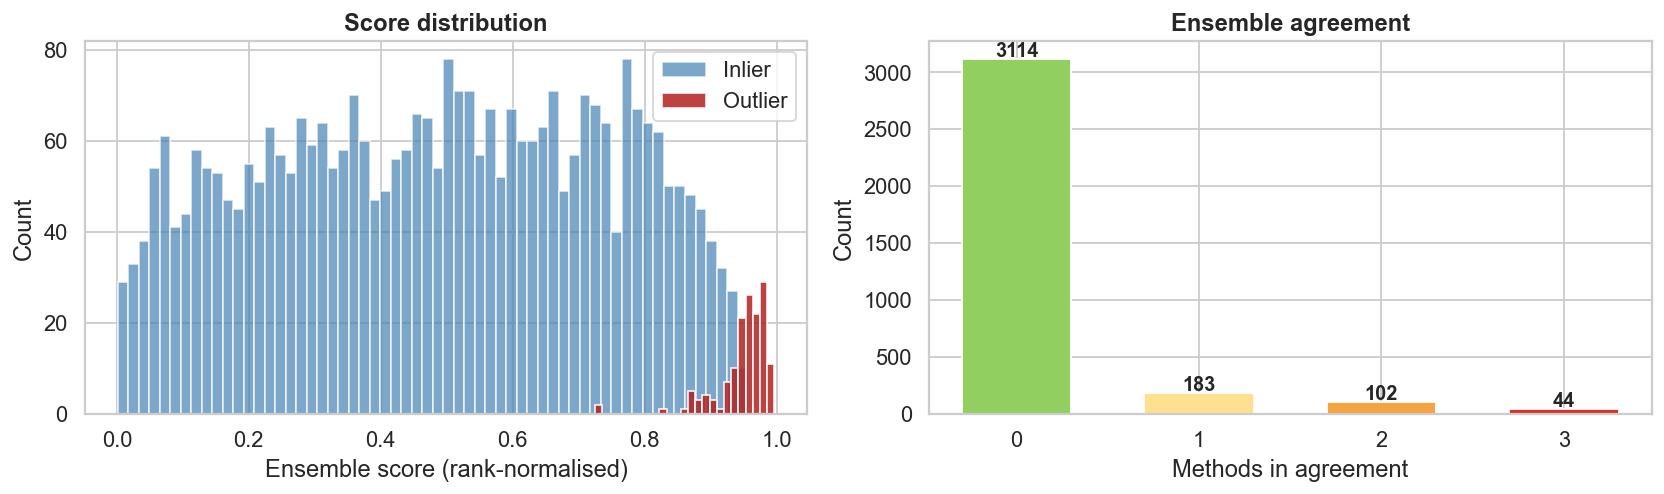

In [13]:
rank_norm = lambda s: pd.Series(s).rank(pct=True).values #rank-normalise scores to [0,1] to compare them across methods
ensemble = (rank_norm(scores_iso) + rank_norm(scores_lof) + rank_norm(scores_svm)) / 3

#score distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(ensemble[labels==0], bins=60, alpha=0.7, color='steelblue', label='Inlier')
axes[0].hist(ensemble[labels==1], bins=25, alpha=0.85, color='firebrick', label='Outlier')
axes[0].set_xlabel('Ensemble score (rank-normalised)')
axes[0].set_ylabel('Count')
axes[0].set_title('Score distribution', fontweight='bold')
axes[0].legend()

#agreement distribution for outliers
vc = pd.Series(votes).value_counts().sort_index()
cols = ['#91cf60', '#fee090', '#f4a441', '#d73027']
axes[1].bar(vc.index, vc.values, color=cols[:len(vc)], edgecolor='white', width=0.6)
for x, y in zip(vc.index, vc.values):
    axes[1].text(x, y + 20, str(y), ha='center', fontsize=11, fontweight='bold')
axes[1].set_xticks([0,1,2,3])
axes[1].set_xlabel('Methods in agreement')
axes[1].set_ylabel('Count')
axes[1].set_title('Ensemble agreement', fontweight='bold')

plt.tight_layout()
plt.show()


44 points flagged by all 3 methods - high-confidence outliers

105 additional points flagged by exactly 2 - included in final labels


## Save Labels

In [15]:
test_labels = pd.DataFrame({'class': labels}, index=df.index)
test_labels.to_csv('test_labels.csv')

print('Saved: test_labels.csv')
print(f'class=1 (outlier): {labels.sum()}')
print(f'class=0 (inlier): {(labels==0).sum()}')


Saved: test_labels.csv
class=1 (outlier): 146
class=0 (inlier): 3297
